# Chapter 6 - Advanced Logistic Regression and Extensions

Reproduksi pembelajaran **scikit-learn Cookbook, Third Edition**, John Sukup (Packt, 2025), untuk mata kuliah Pembelajaran Mesin.

Kode diadaptasi dari [repo penerbit](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500/Chapter_6) beserta exercise solutions. Teori dan interpretasi disusun dalam bahasa Indonesia. Perubahan penting dijelaskan di README. Dataset sintetis diberi label, output disimpan, dan seluruh notebook dapat dijalankan ulang dari kernel baru.

## Daftar Isi

- [Overview of Logistic Regression](#overview-of-logistic-regression)
- [Multiclass Classification Techniques](#multiclass-classification-techniques)
- [Regularization in Logistic Regression](#regularization-in-logistic-regression)
- [Multilabel Classification Concepts](#multilabel-classification-concepts)
- [Model Evaluation Metrics](#model-evaluation-metrics)
- [Practical Exercises with Advanced Logistic Regression](#practical-exercises-with-advanced-logistic-regression)
- [Pemeriksaan Hasil](#pemeriksaan-hasil)
- [Ringkasan Bab](#ringkasan-bab)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.utils import Bunch

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'data'
np.random.seed(2024)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 25)
plt.rcParams.update({'figure.dpi': 100, 'savefig.bbox': 'tight'})

## Overview of Logistic Regression

Logistic regression adalah classifier meskipun namanya regression. Untuk dua kelas, $P(y=1|x)=1/(1+e^{-(\beta_0+x^T\beta)})$ dan log-odds linear terhadap fitur. Parameter dipelajari melalui log-loss, dengan penalti bila digunakan. Probabilitas dan label berbeda: `predict_proba` memberi peluang model, sementara `predict` menerapkan aturan kelas.

Contoh Breast Cancer memakai 569 sampel dan 30 fitur. Dataset memberi label 0 untuk malignant dan 1 untuk benign; metrik binary default di bagian evaluasi memakai benign sebagai positive class. Ini penting agar recall tidak keliru dibaca sebagai kemampuan mendeteksi malignant.

In [2]:
# Load libraries 
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Convert to DataFrame for easier manipulation (optional)
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

# Split the Data
X_train, X_test, y_train, y_test = train_test_split(df[data.feature_names], 
                                                    df['target'], 
                                                    test_size=0.2, 
                                                    random_state=2024)

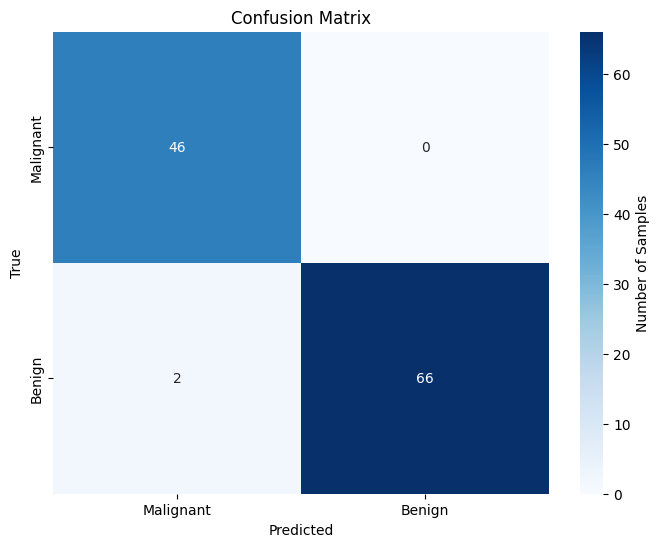

Accuracy: 0.98


Classification Report:


,precision,recall,f1-score,support
Malignant,0.958,1.000,0.979,46
Benign,1.000,0.971,0.985,68
accuracy,0.982,0.982,0.982,1
macro avg,0.979,0.985,0.982,114
weighted avg,0.983,0.982,0.983,114


In [3]:
# Create a Logistic Regression Model 
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000, random_state=2024)) # Increase max_iter if convergence issues occur 

# Train the Model 
model.fit(X_train, y_train)

# Make Predictions 
y_pred = model.predict(X_test) 

# Evaluate Performance
accuracy = accuracy_score(y_test, y_pred)

# Generate and plot confusion matrix
class_names = ['Malignant', 'Benign']
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names, 
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Get classification report as a dictionary
report_dict = classification_report(y_test, y_pred,
                                  target_names=class_names, 
                                  output_dict=True)

# Create a DataFrame for better visualization
report_df = pd.DataFrame(report_dict).transpose()

# Style the DataFrame
styled_df = (report_df
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}', 
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)

print(f'Accuracy: {accuracy:.2f}\n')
print("\nClassification Report:")
display(styled_df)

binary_test_accuracy = accuracy

## Multiclass Classification Techniques

One-vs-rest melatih satu classifier biner untuk setiap kelas terhadap kelas lainnya. Multinomial logistic regression menggunakan softmax dan loss bersama untuk kelas yang saling eksklusif. Iris memiliki tiga kelas; perbandingan memakai split yang sama. OvR eksplisit memakai OneVsRestClassifier agar strategi tidak bergantung pada perilaku solver versi library.

Pairplot adalah eksplorasi hubungan fitur dan kelas, bukan evaluasi generalisasi. Probabilitas multinomial tiap baris berjumlah satu; probabilitas model tetap perlu diperiksa kalibrasinya jika dipakai sebagai tingkat keyakinan.

In [4]:
# Load the libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.inspection import DecisionBoundaryDisplay
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [5]:
from sklearn.multiclass import OneVsRestClassifier
# Create and train an OvR Logistic Regression model
ovr_model = OneVsRestClassifier(LogisticRegression(solver='liblinear', random_state=2024))
ovr_model.fit(X_train, y_train)

# Create and train and Multinomial Logistic Regression model
multinomial_model = LogisticRegression(solver='lbfgs', max_iter = 1000)
multinomial_model.fit(X_train, y_train)

# Make predictions with the OvR model
y_pred_ovr = ovr_model.predict(X_test)

# Make predictions with the Multinomial model
y_pred_multinomial = multinomial_model.predict(X_test)

# Evaluate the OvR model
accuracy_ovr = accuracy_score(y_test, y_pred_ovr)
report_ovr = pd.DataFrame(classification_report(y_test, y_pred_ovr, output_dict=True)).transpose()
print("One-vs-Rest (OvR) Logistic Regression:")

styled_ovr = (report_ovr
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_ovr)

# Evaluate the Multinomial model
accuracy_multinomial = accuracy_score(y_test, y_pred_multinomial)
report_multinomial = pd.DataFrame(classification_report(y_test, y_pred_multinomial, output_dict=True)).transpose()
print("Multinomial Logistic Regression:")

styled_multinomial = (report_multinomial
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_multinomial)

iris_multinomial_probabilities = multinomial_model.predict_proba(X_test)

One-vs-Rest (OvR) Logistic Regression:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.917,0.917,0.917,12
2,0.933,0.933,0.933,15
accuracy,0.956,0.956,0.956,1
macro avg,0.950,0.950,0.950,45
weighted avg,0.956,0.956,0.956,45


Multinomial Logistic Regression:


,precision,recall,f1-score,support
0,1.000,1.000,1.000,18
1,0.846,0.917,0.880,12
2,0.929,0.867,0.897,15
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.928,0.926,45
weighted avg,0.935,0.933,0.934,45


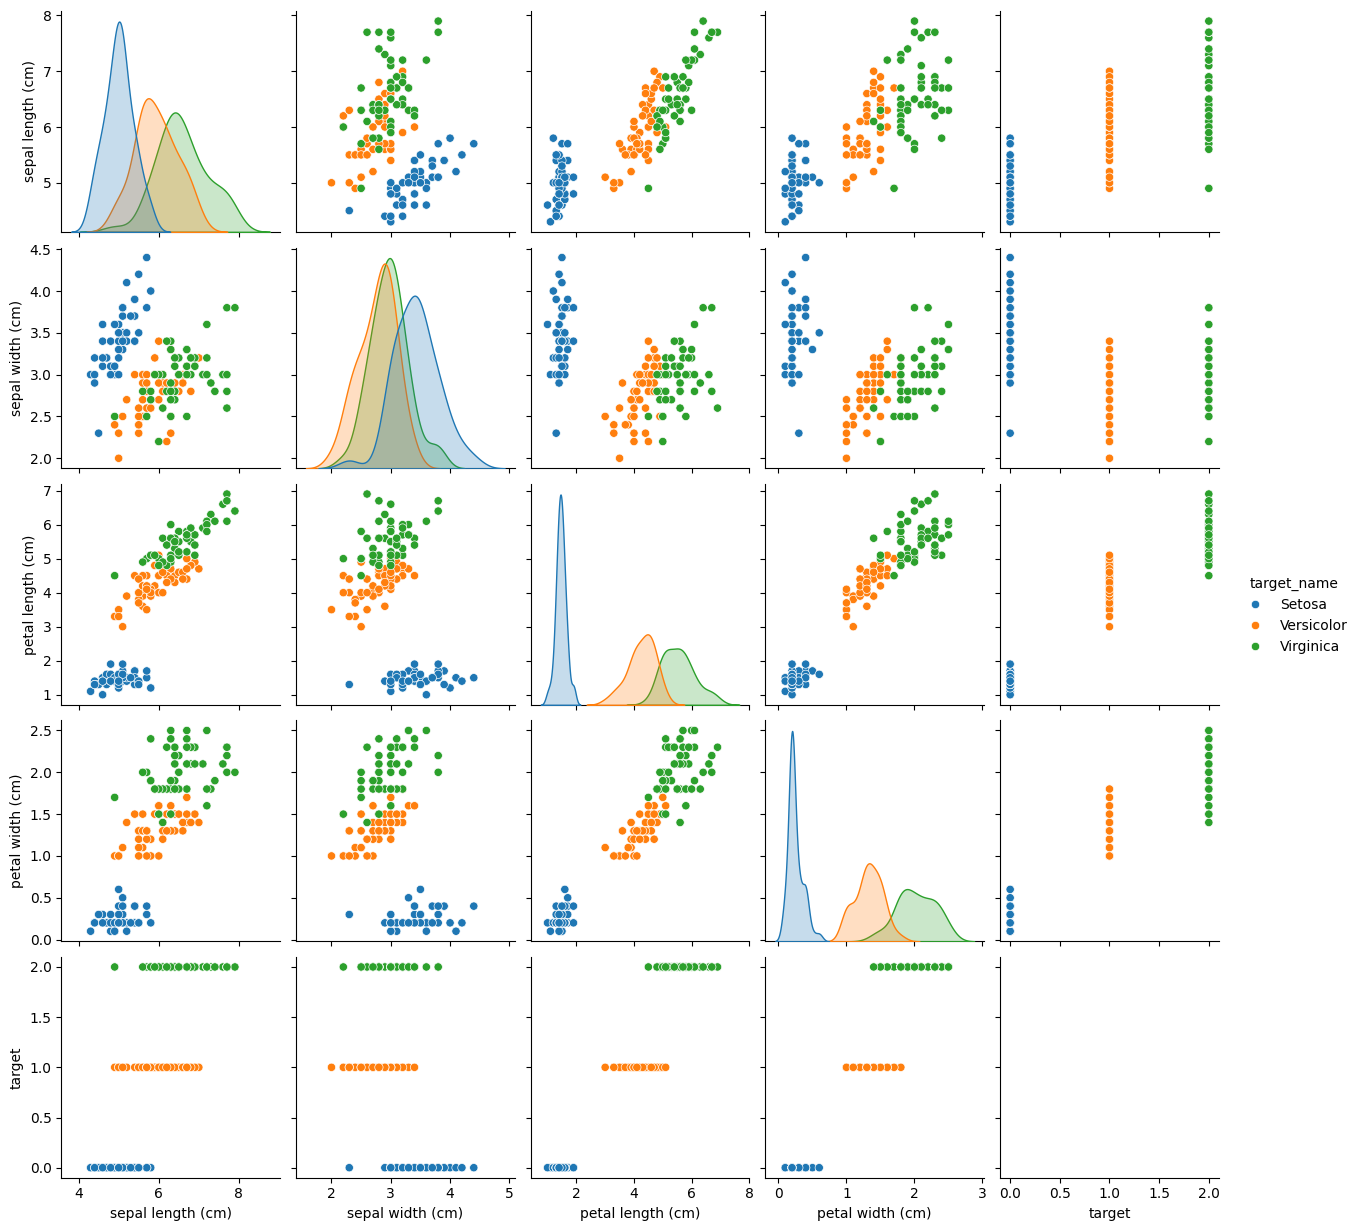

In [6]:
# Create a pairplot to visualize the data 
target_names = {0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'}
df['target_name'] = df['target'].map(target_names)
sns.pairplot(df, hue='target_name', diag_kind='kde')
plt.show()

## Regularization in Logistic Regression

Penalti L2 menyusutkan koefisien, L1 dapat menghasilkan sparsity, dan ElasticNet menggabungkannya dengan solver yang mendukung. `C` adalah inverse regularization strength: C kecil berarti penalti lebih kuat, berbeda arah dari alpha pada Ridge/Lasso. Scaling dipelajari dari training sebelum penalti dibandingkan.

Class imbalance dapat ditangani melalui class_weight atau sample_weight dengan mempertimbangkan biaya kesalahan. Threshold dapat diubah berdasarkan precision–recall trade-off pada validation. Coefficient path terhadap C menjelaskan shrinkage; ukuran koefisien bukan ukuran signifikansi atau bukti kausal.

In [7]:
# Load the libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split the dataset and scale it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Create and train a Ridge (L2) regularized Logistic Regression model
ridge_model = LogisticRegression(penalty='l2', solver='liblinear', random_state=2024, C=0.1)
ridge_model.fit(X_train, y_train)

# Create and train a Lasso (L1) regularized Logistic Regression model
lasso_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=2024, C=0.1)
lasso_model.fit(X_train, y_train)

# Make predictions with the Ridge model
y_pred_ridge = ridge_model.predict(X_test)

# Make predictions with the Lasso model
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the Ridge model
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
report_ridge = pd.DataFrame(classification_report(y_test, y_pred_ridge, output_dict=True)).transpose()
print("Ridge (L2) Regularized Logistic Regression:")

styled_ridge = (report_ridge
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_ridge)

# Evaluate the Lasso model
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
report_lasso = pd.DataFrame(classification_report(y_test, y_pred_lasso, output_dict=True)).transpose()
print("Lasso (L1) Regularized Logistic Regression:")

styled_lasso = (report_lasso
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_lasso)

Ridge (L2) Regularized Logistic Regression:


,precision,recall,f1-score,support
0,0.985,0.970,0.977,67
1,0.981,0.990,0.986,104
accuracy,0.982,0.982,0.982,1
macro avg,0.983,0.980,0.982,171
weighted avg,0.982,0.982,0.982,171


Lasso (L1) Regularized Logistic Regression:


,precision,recall,f1-score,support
0,0.930,0.985,0.957,67
1,0.990,0.952,0.971,104
accuracy,0.965,0.965,0.965,1
macro avg,0.960,0.968,0.964,171
weighted avg,0.966,0.965,0.965,171


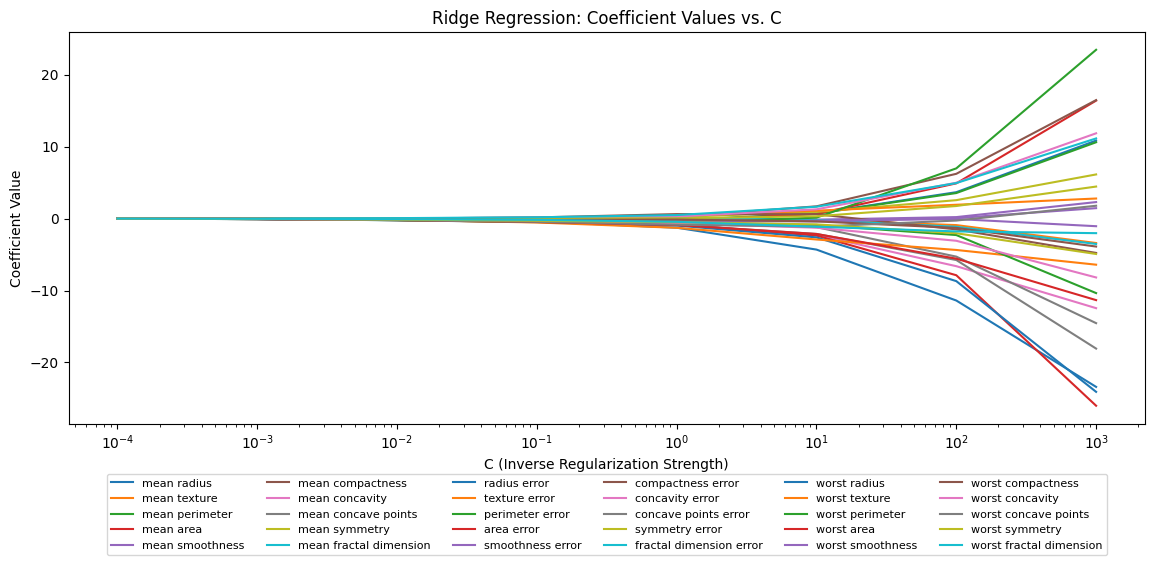

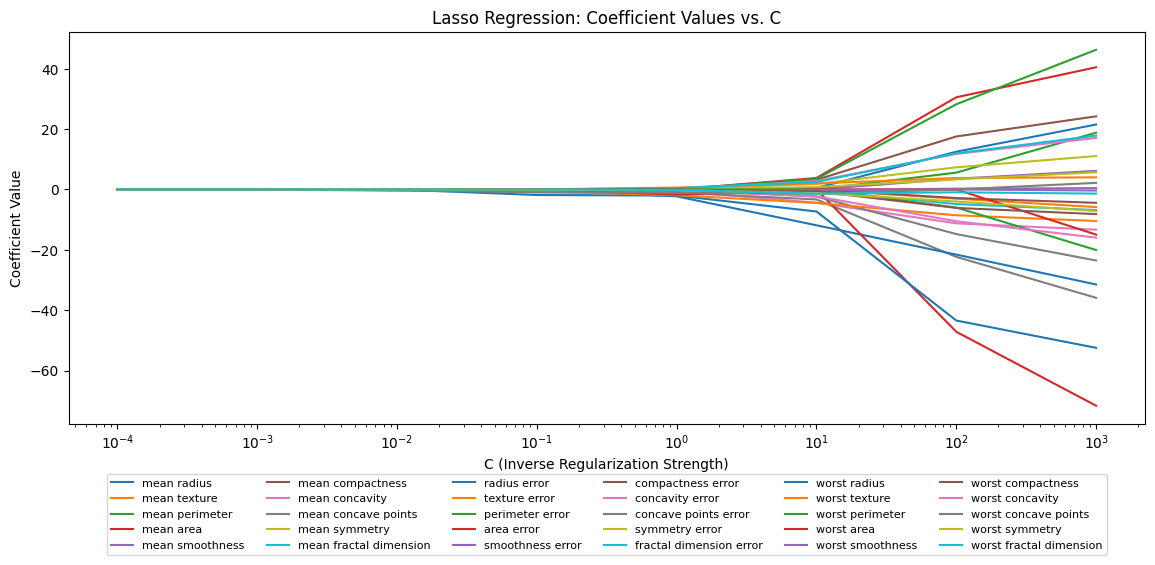

In [9]:
# Plotting coefficients for different C values (Ridge)
C_values = np.array([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
coefs_ridge = []

for C in C_values:
    ridge_model = LogisticRegression(penalty='l2', solver='liblinear', random_state=2024, C=C)
    ridge_model.fit(X_train, y_train)
    coefs_ridge.append(ridge_model.coef_[0])

plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
    plt.plot(C_values, [coef[i] for coef in coefs_ridge], label=feature_names[i])
plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Ridge Regression: Coefficient Values vs. C')
plt.legend(bbox_to_anchor=(0.5, -0.35), ncol=6, loc='lower center', fontsize=8)
plt.tight_layout()
plt.show()

# Plotting coefficients for different C values (Lasso)
C_values = np.array([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
coefs_lasso = []

for C in C_values:
    lasso_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=2024, C=C)
    lasso_model.fit(X_train, y_train)
    coefs_lasso.append(lasso_model.coef_[0])

plt.figure(figsize=(12, 6))
for i in range(X.shape[1]):
    plt.plot(C_values, [coef[i] for coef in coefs_lasso], label=feature_names[i])
plt.xscale('log')
plt.xlabel('C (Inverse Regularization Strength)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Regression: Coefficient Values vs. C')
plt.legend(bbox_to_anchor=(0.5, -0.35), ncol=6, loc='lower center', fontsize=8)
plt.tight_layout()
plt.show()

## Multilabel Classification Concepts

Multiclass memberi tepat satu kelas per sampel, sedangkan multilabel mengizinkan beberapa label sekaligus. Target sintetis berbentuk matriks 1.000×5 dengan indikator binary. Binary relevance melatih model terpisah untuk tiap label; pendekatan ini tidak langsung memodelkan ketergantungan label. OneVsRestClassifier dapat merangkum workflow tersebut, sedangkan classifier chain memakai prediksi label sebelumnya dan membutuhkan evaluasi yang sesuai.

Subset accuracy mensyaratkan seluruh label pada sampel benar, sehingga lebih ketat daripada accuracy per label. Hamming loss mengukur proporsi indikator yang salah. Micro F1 menggabungkan hitungan seluruh label; macro F1 merata-ratakan skor label. Tabel co-occurrence menampilkan frekuensi bersama, dan normalisasi per baris memberi proporsi kondisional yang tidak harus simetris.

In [10]:
# Load the libraries
from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
X, y = make_multilabel_classification(n_samples=1000, n_features=20, n_classes=5, n_labels=2, random_state=2024)
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = list(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

In [11]:
# Since we have multiple labels, we need to train a separate model for each label
models = []
y_pred_all = []

# Train a model for each label (column) in y
for i in range(y_train.shape[1]):
    # Create and train model for this label
    model = LogisticRegression(solver='liblinear', random_state=2024)
    model.fit(X_train, y_train[:, i])
    models.append(model)

    # Make predictions for this label
    y_pred_label = model.predict(X_test)
    y_pred_all.append(y_pred_label)

# Convert predictions list to array and transpose to match original format
y_pred = np.array(y_pred_all).T

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = pd.DataFrame(classification_report(y_test, y_pred, zero_division=0, output_dict=True)).transpose()
print("Classification Report:")

styled_report = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_report)

from sklearn.metrics import hamming_loss
multilabel_subset_accuracy = accuracy
multilabel_hamming = hamming_loss(y_test, y_pred)
multilabel_target_shape = y_test.shape
multilabel_prediction_shape = y_pred.shape
print('Subset accuracy:', accuracy, 'Hamming loss:', multilabel_hamming)

Classification Report:


,precision,recall,f1-score,support
0,0.808,0.813,0.811,166
1,0.801,0.845,0.823,181
2,0.674,0.333,0.446,93
3,0.750,0.176,0.286,34
4,0.575,0.477,0.522,88
micro avg,0.757,0.653,0.701,562
macro avg,0.722,0.529,0.577,562
weighted avg,0.744,0.653,0.677,562
samples avg,0.721,0.609,0.620,562


Subset accuracy: 0.34 Hamming loss: 0.20866666666666667



Label Statistics:
Total samples: 300

Label frequencies:
Label 0: 166 samples (55.3%)
Label 1: 181 samples (60.3%)
Label 2: 93 samples (31.0%)
Label 3: 34 samples (11.3%)
Label 4: 88 samples (29.3%)

Most common label combinations:
Combination [0 0 0 0 0]: 52 samples (17.3%)
Combination [0 1 0 0 0]: 34 samples (11.3%)
Combination [1 1 0 0 0]: 28 samples (9.3%)
Combination [1 1 1 0 0]: 25 samples (8.3%)
Combination [1 1 0 0 1]: 24 samples (8.0%)


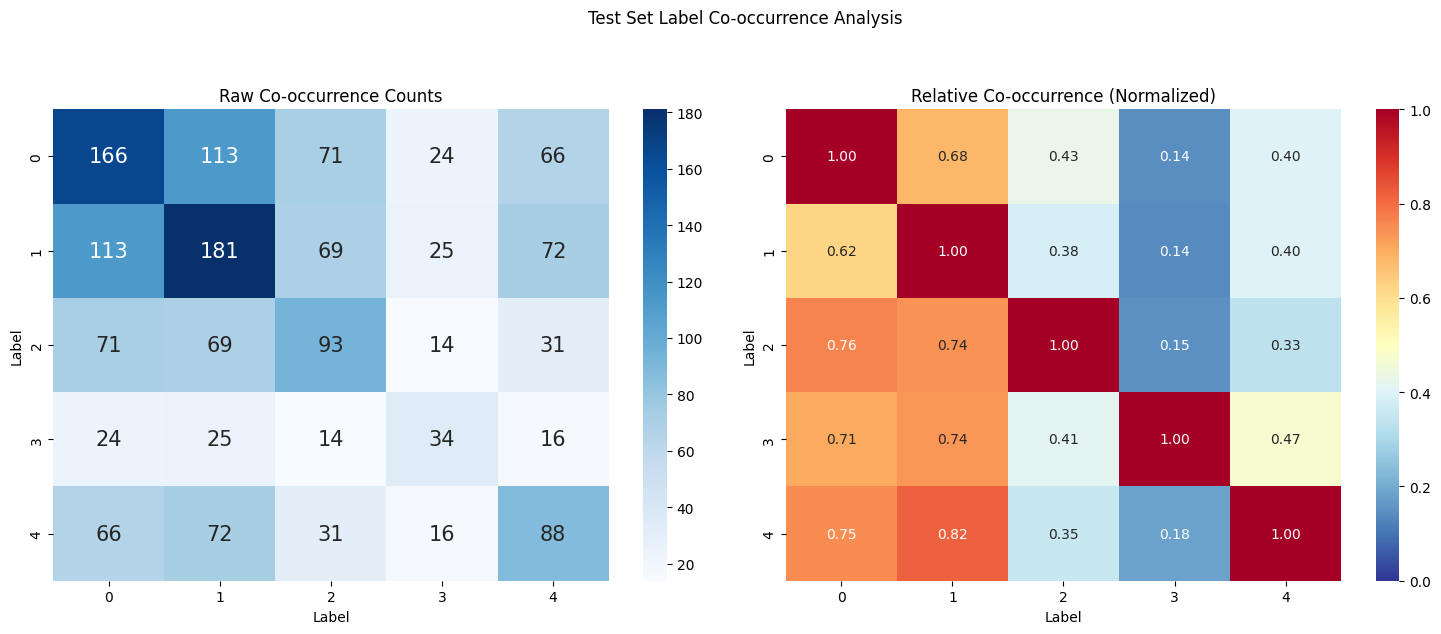

In [12]:
# Create a detailed label co-occurrence visualization
def plot_label_cooccurrence(y, title="Label Co-occurrence Analysis"):
    # Compute raw co-occurrence counts
    cooccurrence = y.T @ y

    # Compute relative co-occurrence (normalized by diagonal)
    # This shows what percentage of time label i occurs with label j
    diag = np.diag(cooccurrence)
    relative_cooccurrence = cooccurrence / diag[:, None]

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Plot raw co-occurrence
    sns.heatmap(cooccurrence, annot=True, fmt='d', cmap='Blues', 
                ax=ax1, annot_kws={"fontsize": 15})
    ax1.set_title('Raw Co-occurrence Counts')
    ax1.set_xlabel('Label')
    ax1.set_ylabel('Label')

    # Plot relative co-occurrence
    sns.heatmap(relative_cooccurrence, annot=True, fmt='.2f', 
                cmap='RdYlBu_r', ax=ax2, annot_kws={"fontsize": 10},
                vmin=0, vmax=1)
    ax2.set_title('Relative Co-occurrence (Normalized)')
    ax2.set_xlabel('Label')
    ax2.set_ylabel('Label')

    plt.suptitle(title, y=1.05)
    plt.tight_layout()

    # Print additional statistics
    print("\nLabel Statistics:")
    print(f"Total samples: {len(y)}")
    print("\nLabel frequencies:")
    for i in range(y.shape[1]):
        count = y[:, i].sum()
        percentage = count / len(y) * 100
        print(f"Label {i}: {count} samples ({percentage:.1f}%)")

    print("\nMost common label combinations:")
    # Get unique combinations and their counts
    unique_combinations = np.unique(y, axis=0, return_counts=True)
    sorted_idx = np.argsort(-unique_combinations[1])  # Sort by count (descending)
    for combo, count in zip(unique_combinations[0][sorted_idx][:5], 
                          unique_combinations[1][sorted_idx][:5]):
        percentage = count / len(y) * 100
        print(f"Combination {combo}: {count} samples ({percentage:.1f}%)")

# Use the function on your test data
plot_label_cooccurrence(y_test, "Test Set Label Co-occurrence Analysis")

## Model Evaluation Metrics

Accuracy adalah proporsi prediksi benar; precision $TP/(TP+FP)$, recall $TP/(TP+FN)$, dan F1 harmonic mean keduanya. ROC memetakan TPR terhadap FPR untuk berbagai threshold; AUC mengukur kemampuan ranking, bukan accuracy atau kalibrasi probabilitas. Precision–recall lebih informatif pada beberapa masalah kelas positif langka.

Contoh ROC memakai peluang benign (label 1), sesuai target dataset. Pemilihan threshold dan hyperparameter dilakukan pada training/validation; test tidak dipakai berulang untuk mencari hasil terbaik. Undefined precision/recall tidak diganti menjadi 1; contoh menggunakan zero_division=0 dan menjelaskan label positifnya.

In [13]:
# Load the libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

Accuracy 0.98
Precision 1.00
Recall 0.97
F1 Score 0.99
ROC AUC 1.00
Classification Report:


,precision,recall,f1-score,support
0,0.957,1.000,0.978,67
1,1.000,0.971,0.985,104
accuracy,0.982,0.982,0.982,1
macro avg,0.979,0.986,0.982,171
weighted avg,0.983,0.982,0.983,171


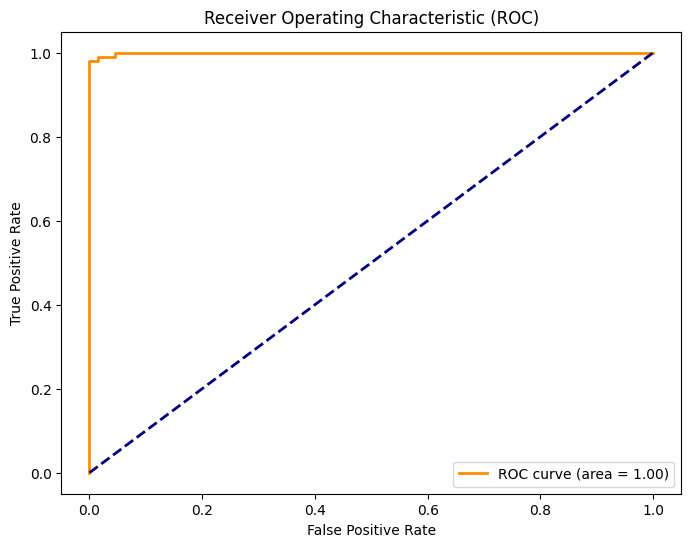

In [14]:
# Load the model
model = make_pipeline(StandardScaler(), LogisticRegression(solver='liblinear', random_state=2024))

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
report = pd.DataFrame(classification_report(y_test, y_pred, zero_division=0, output_dict=True)).transpose()

# Print the metrics
print(f"Accuracy {accuracy:.2f}")
print(f"Precision {precision:.2f}")
print(f"Recall {recall:.2f}")
print(f"F1 Score {f1:.2f}")
print(f"ROC AUC {roc_auc:.2f}")
print("Classification Report:")

styled_report = (report
    .style
    .background_gradient(cmap='Blues', subset=['precision', 'recall', 'f1-score'])
    .format({
        'precision': '{:.3f}',
        'recall': '{:.3f}',
        'f1-score': '{:.3f}',
        'support': '{:.0f}'
    })
)
display(styled_report)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

binary_roc_auc = roc_auc

## Practical Exercises with Advanced Logistic Regression

Latihan melatih classifier L1 pada Breast Cancer, classifier multinomial pada Iris, dan visualisasi keputusan pada dua fitur sintetis. Preprocessing Breast Cancer belajar dari training. Kontur pada latihan adalah label hasil `predict`, bukan probabilitas; batas pada plot menunjukkan pembagian kelas untuk model dan fitur tersebut.

### Latihan 1: Implementing Ridge Regression

Pipeline scaling dan logistic regression L1 dilatih pada Breast Cancer. Statistik scaling berasal dari training dan accuracy dihitung pada test.

In [15]:
#Load libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Load the dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Create and train a Lasso regularized Logistic Regression model
lasso_model = make_pipeline(StandardScaler(), LogisticRegression(penalty='l1', solver='liblinear', random_state=2024, max_iter=10000, C=0.1))
lasso_model.fit(X_train, y_train)

# Make predictions with the Lasso model
y_pred_lasso = lasso_model.predict(X_test)

# Evaluate the Lasso model performance
accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
print(f"Lasso Model Accuracy: {accuracy_lasso:.2f}")

Lasso Model Accuracy: 0.96


### Latihan 2: Evaluating Multiclass Logistic Regression

Model multinomial Iris mengevaluasi tiga kelas yang saling eksklusif. Accuracy mengukur label prediksi, bukan kalibrasi probabilitas.

In [16]:
# Load the libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load the dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Create and train a Multinomial Logistic Regression model
multinomial_model = LogisticRegression(solver='lbfgs', max_iter=1000)
multinomial_model.fit(X_train, y_train)

# Make predictions with the Multinomial model
y_pred_multinomial = multinomial_model.predict(X_test)

# Evaluate the Multinomial model performance
accuracy_multinomial = accuracy_score(y_test, y_pred_multinomial)
print(f"Multinomial Model Accuracy: {accuracy_multinomial:.2f}")

Multinomial Model Accuracy: 0.93


### Latihan 3: Visualizing Logistic Regression Results

Data sintetis dua fitur dipakai untuk menampilkan batas label logistic regression. Kontur berasal dari predict, sehingga warna menunjukkan kelas keputusan.

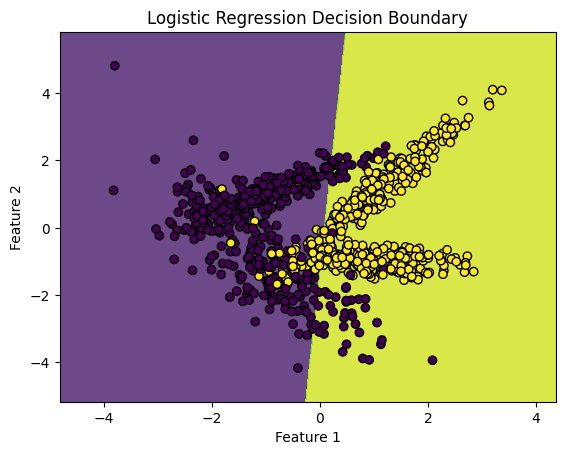

In [17]:
# Load libraries for visualization and dataset creation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Create synthetic dataset for binary classification
X, y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_informative=2, n_redundant=0, random_state=2024)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2024)

# Create and train a Logistic Regression model
logistic_model = LogisticRegression(random_state=2024, max_iter=2000)
logistic_model.fit(X_train, y_train)

# Create a mesh grid for plotting decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict class probabilities across the grid
Z = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundaries
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o')
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Pemeriksaan Hasil

Angka berikut merangkum hasil eksekusi, disertai assertion untuk memeriksa konsistensi tertentu. Pemeriksaan kode tidak membuktikan asumsi statistik atau representativitas data.

In [18]:
chapter_results = {'binary_test_accuracy': float(binary_test_accuracy),
 'iris_ovr_accuracy': float(accuracy_ovr),
 'iris_multinomial_accuracy': float(accuracy_multinomial),
 'multilabel_subset_accuracy': float(multilabel_subset_accuracy),
 'multilabel_hamming_loss': float(multilabel_hamming),
 'benign_roc_auc': float(binary_roc_auc)}
assert multilabel_target_shape == multilabel_prediction_shape
assert np.allclose(iris_multinomial_probabilities.sum(axis=1), 1)
assert 0 <= binary_roc_auc <= 1
print(json.dumps(chapter_results, indent=2))

{
  "binary_test_accuracy": 0.9824561403508771,
  "iris_ovr_accuracy": 0.9555555555555556,
  "iris_multinomial_accuracy": 0.9333333333333333,
  "multilabel_subset_accuracy": 0.34,
  "multilabel_hamming_loss": 0.20866666666666667,
  "benign_roc_auc": 0.9994259471871412
}


## Ringkasan Bab

Classifier binary Breast Cancer menghasilkan **accuracy test 98.25%** pada split awal. Pada Iris, OvR menghasilkan **95.56%** dan multinomial **93.33%**. Perbandingan satu split ini tidak membuktikan satu strategi selalu lebih baik. C yang lebih kecil berarti regularisasi lebih kuat, dan scaling memengaruhi interpretasi penalti.

Pada contoh multilabel, **subset accuracy 34.00%** mensyaratkan seluruh indikator label benar pada sampel, sedangkan **Hamming loss 0.2087** mengukur proporsi indikator yang salah. Dua metrik ini tidak saling bertentangan karena unit evaluasinya berbeda. ROC-AUC pada bagian evaluasi binary sekitar **0.9994** memakai benign sebagai positive class; hasilnya tidak boleh dibaca sebagai recall malignant. Probabilitas, label keputusan, ranking, dan kalibrasi merupakan hal yang berbeda.